<a href="https://colab.research.google.com/github/TissianyDelmiro/analise-de-dados-progrAmo/blob/main/regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # Importa a biblioteca pandas, que é amplamente utilizada para manipulação e análise de dados.

In [ ]:
dados = pd.read_excel('/content/drive/MyDrive/Myanalytics_projects/analise_dados_mod7_(1).xlsx') # Carrega os dados de um arquivo Excel localizado no Google Drive para um DataFrame do pandas chamado 'dados'.

In [ ]:
dados.head() # Exibe as primeiras 5 linhas do DataFrame 'dados' para ter uma visão geral dos dados e de suas colunas.

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


In [ ]:
dados.columns # Mostra os nomes de todas as colunas presentes no DataFrame 'dados'.

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts() # Conta a frequência de cada valor único na coluna 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'.

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [ ]:
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?']=='Empregado (CLT)'] # Filtra o DataFrame 'dados' para incluir apenas as linhas onde a coluna 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?' é 'Empregado (CLT)'.

In [ ]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts() # Após o filtro, re-verifica a contagem de valores na coluna 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?' para confirmar que apenas 'Empregado (CLT)' permaneceu.

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


In [ ]:
dados['COR/RACA/ETNIA'].value_counts() # Conta a frequência de cada valor único na coluna 'COR/RACA/ETNIA'.

,count
COR/RACA/ETNIA,
Branca,1805
Parda,661
Preta,181
Amarela,85
Prefiro não informar,16
Outra,10
Indígena,4


In [ ]:
lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena'] # Define uma lista de categorias de 'COR/RACA/ETNIA' que serão removidas do DataFrame.

In [ ]:
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)] # Filtra o DataFrame para remover as linhas cujos valores na coluna 'COR/RACA/ETNIA' estão na 'lista_retirar'.

In [ ]:
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x!= 'Branca' else 0) # Cria uma nova coluna 'NAO_BRANCA'. Ela recebe 1 se a 'COR/RACA/ETNIA' não for 'Branca', e 0 caso contrário.

In [ ]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts() # Conta a frequência de cada valor único na coluna 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'.

,count
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,
de 1 a 2 anos,743
de 3 a 4 anos,584
de 4 a 6 anos,416
Menos de 1 ano,353
Mais de 10 anos,277
de 7 a 10 anos,232
Não tenho experiência na área de dados,127


In [ ]:
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)') # Extrai o primeiro número (dígito) da string da coluna de experiência e cria uma nova coluna 'TEMPO_EXPERIENCIA' com esses valores.

In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts() # Verifica a contagem de valores únicos na nova coluna 'TEMPO_EXPERIENCIA'.

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232


In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts() # Conta a frequência de cada valor único na coluna 'NUMERO DE FUNCIONARIOS'.

,count
NUMERO DE FUNCIONARIOS,
Acima de 3.000,1313
de 101 a 500,503
de 1.001 a 3.000,368
de 501 a 1.000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [ ]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '') # Remove todos os pontos ('.') das strings na coluna 'NUMERO DE FUNCIONARIOS'.

In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts() # Verifica a contagem de valores únicos na coluna 'NUMERO DE FUNCIONARIOS' após a remoção dos pontos.

,count
NUMERO DE FUNCIONARIOS,
Acima de 3000,1313
de 101 a 500,503
de 1001 a 3000,368
de 501 a 1000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [ ]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)') # Extrai o primeiro número (dígito) da string da coluna 'NUMERO DE FUNCIONARIOS' para padronizar os dados.

In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts() # Verifica a contagem de valores únicos na coluna 'NUMERO DE FUNCIONARIOS' após a extração dos números.

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False) # Verifica novamente a contagem de valores únicos na coluna 'NUMERO DE FUNCIONARIOS', incluindo valores nulos (NaN), se houver.

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False) # Verifica a contagem de valores únicos na coluna 'TEMPO_EXPERIENCIA', incluindo valores nulos (NaN).

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
NaN,127


In [ ]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0) # Preenche os valores nulos (NaN) na coluna 'TEMPO_EXPERIENCIA' com zero.

In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False) # Verifica a contagem de valores únicos na coluna 'TEMPO_EXPERIENCIA' após preencher os valores nulos.

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
0,127


In [ ]:
dados.columns # Exibe novamente todos os nomes das colunas do DataFrame 'dados' para verificar as alterações.

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts() # Conta a frequência de cada motivo de insatisfação na coluna 'Qual o principal motivo da sua insatisfação com a empresa atual?'.

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,69
Salário atual não corresponde ao mercado,53
Falta de oportunidade de crescimento no emprego atual,46
Falta de maturidade analítica na empresa,45
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",26
...,...
"O clima de trabalho/ambiente não é bom, Não tenho uma boa relação com meu líder/gestor, Gostaria de receber mais benefícios",1
Falta de organização nos processos internos,1
"Gostaria de receber mais benefícios, O clima de trabalho/ambiente não é bom, Falta de oportunidade de crescimento no emprego atual",1


In [ ]:
dados['INSATISFAÇÃO'] = 0 # Inicializa uma nova coluna 'INSATISFAÇÃO' com o valor 0 para todas as linhas.

In [ ]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0) # Este bloco de código demonstra como a função `apply` seria usada para verificar se 'Salário' está presente nos motivos de insatisfação.

,Qual o principal motivo da sua insatisfação com a empresa atual?
1,0
2,0
7,1
10,0
26,1
...,...
4227,0
4234,1
4238,0
4240,1


In [ ]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFAÇÃO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0) # Atualiza a coluna 'INSATISFAÇÃO': se a coluna 'Qual o principal motivo da sua insatisfação com a empresa atual?' não for nula e contiver a palavra 'Salário', a 'INSATISFAÇÃO' recebe 1; caso contrário, permanece 0.

In [ ]:
dados['INSATISFAÇÃO'].value_counts() # Conta a frequência de 0s e 1s na coluna 'INSATISFAÇÃO' para ver a distribuição.

,count
INSATISFAÇÃO,
0,2453
1,279


In [ ]:
dados['NIVEL DE ENSINO'].value_counts() # Conta a frequência de cada nível de ensino na coluna 'NIVEL DE ENSINO'.

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1024
Pós-graduação,975
Mestrado,306
Estudante de Graduação,271
Doutorado ou Phd,100
Não tenho graduação formal,52
Prefiro não informar,4


In [ ]:
dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x== 'Não tenho graduação formal' else
                               1 if x== 'Estudante de Graduação' else
                               2 if x== 'Graduação/Bacharelado'else
                               3 if x== 'Pós-graduação' else
                               4 if x==  'Mestrado' else
                               5 if x== 'Doutorado ou Phd' else -1) # Este bloco de código demonstra como mapear os níveis de ensino textuais para valores numéricos, mas não atribui o resultado de volta à coluna.

,NIVEL DE ENSINO
1,2
2,3
3,5
6,1
7,2
...,...
4262,3
4263,2
4266,2
4267,4


In [ ]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x== 'Não tenho graduação formal' else
                               1 if x== 'Estudante de Graduação' else
                               2 if x== 'Graduação/Bacharelado'else
                               3 if x== 'Pós-graduação' else
                               4 if x==  'Mestrado' else
                               5 if x== 'Doutorado ou Phd' else -1) # Mapeia os níveis de ensino textuais para valores numéricos, atribuindo um peso maior para níveis de ensino mais elevados, e atualiza a coluna 'NIVEL DE ENSINO'.

In [ ]:
dados['NIVEL DE ENSINO'].value_counts() # Verifica a contagem de valores únicos na coluna 'NIVEL DE ENSINO' após o mapeamento numérico.

,count
NIVEL DE ENSINO,
2,1024
3,975
4,306
1,271
5,100
0,52
-1,4


In [ ]:
dados.columns # Exibe todos os nomes das colunas do DataFrame 'dados'.

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFAÇÃO', 'SETOR', 'REGIAO ONDE MORA',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'SALARIO','NOVO_NIVEL']] # Seleciona um subconjunto específico de colunas do DataFrame 'dados', mantendo apenas as que serão usadas para o modelo.

In [ ]:
dados.columns # Exibe os nomes das colunas do DataFrame 'dados' após a seleção, confirmando as colunas restantes.

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFAÇÃO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')

In [ ]:
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True) # Aplica a técnica One-Hot Encoding (get_dummies) nas colunas categóricas ('GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA').
# Isso transforma cada categoria em uma nova coluna binária (0 ou 1), o que é necessário para modelos de machine learning.
# `drop_first=True` evita a multicolinearidade, removendo uma das colunas criadas para cada variável categórica.

In [ ]:
X = dados.drop('SALARIO', axis=1) # Separa o DataFrame em features (variáveis independentes) e target (variável dependente).
y = dados['SALARIO'] # 'X' contém todas as colunas, exceto 'SALARIO'.
# 'y' contém apenas a coluna 'SALARIO', que é a variável que queremos prever.

In [ ]:
from sklearn.model_selection import train_test_split # Importa a função `train_test_split` do módulo `sklearn.model_selection`.
# Esta função é usada para dividir os dados em conjuntos de treino e teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Divide os dados em conjuntos de treino e teste.
# `X_train`, `y_train` são usados para treinar o modelo.
# `X_test`, `y_test` são usados para avaliar o desempenho do modelo.
# `test_size=0.2` indica que 20% dos dados serão usados para teste.
# `random_state=42` garante que a divisão seja a mesma sempre que o código for executado, para reprodutibilidade.

In [ ]:
from sklearn.preprocessing import StandardScaler # Importa a classe `StandardScaler` do módulo `sklearn.preprocessing`.
# Esta classe é usada para padronizar as features, escalando-as para que tenham média 0 e desvio padrão 1.

In [ ]:
scaler = StandardScaler() # Inicializa o StandardScaler.

X_train_scaled = scaler.fit_transform(X_train) # Aplica a padronização aos conjuntos de treino e teste.
X_test_scaled = scaler.transform(X_test) # `fit_transform` no `X_train` calcula a média e o desvio padrão e depois aplica a transformação.
# `transform` no `X_test` usa a média e o desvio padrão calculados no `X_train` para escalar os dados de teste, evitando vazamento de dados.

In [ ]:
from sklearn.linear_model import LinearRegression # Importa o modelo de Regressão Linear do módulo `sklearn.linear_model`.

In [ ]:
model = LinearRegression() # Inicializa uma instância do modelo de Regressão Linear.

In [ ]:
model.fit(X_train_scaled, y_train) # Treina o modelo de Regressão Linear usando os dados de treino escalados (`X_train_scaled`) e os salários correspondentes (`y_train`).
# O modelo aprende os coeficientes que minimizam o erro quadrático entre as previsões e os valores reais.

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled) # Usa o modelo treinado para fazer previsões nos dados de teste escalados (`X_test_scaled`).
# `y_pred` armazenará os salários previstos pelo modelo para o conjunto de teste.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Importa as métricas de avaliação do modelo: Mean Squared Error (Erro Quadrático Médio), R-squared (R²) e Mean Absolute Error (Erro Absoluto Médio).

In [ ]:
mse = mean_squared_error(y_test, y_pred) # Calcula o Mean Squared Error (MSE) comparando os valores reais de `y_test` com os valores previstos `y_pred`.

In [ ]:
mse # Exibe o valor do Mean Squared Error (MSE).

23235667.570491765

In [ ]:
mae = mean_absolute_error(y_test, y_pred) # Calcula o Mean Absolute Error (MAE) comparando os valores reais de `y_test` com os valores previstos `y_pred`.

In [ ]:
mae # Exibe o valor do Mean Absolute Error (MAE).

3324.59223727014

In [ ]:
import matplotlib.pyplot as plt # Importa a biblioteca `matplotlib.pyplot` para a criação de gráficos.

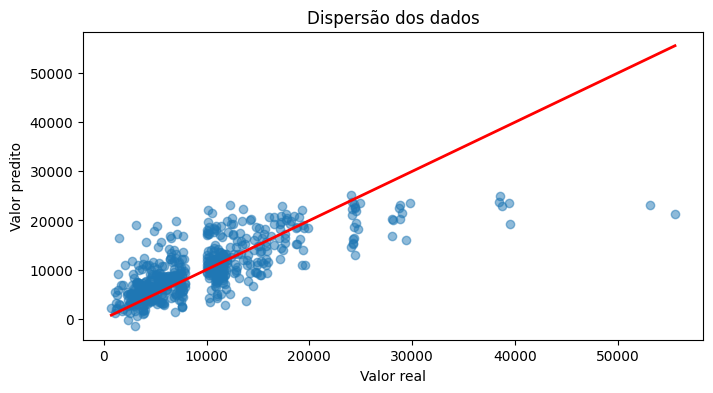

In [ ]:
plt.figure(figsize=(8,4)) # Cria uma figura para o gráfico com um tamanho específico.
plt.scatter(y_test, y_pred, alpha = 0.5) # Plota um gráfico de dispersão (`scatter plot`) comparando os valores reais (`y_test`) com os valores previstos (`y_pred`).
plt.xlabel('Valor real') # Define os rótulos dos eixos X e Y e o título do gráfico.
plt.ylabel('Valor predito')
plt.title('Dispersão dos dados')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2) # Adiciona uma linha diagonal vermelha (onde `y_test` é igual a `y_pred`) para visualizar quão bem as previsões se alinham aos valores reais.
plt.show() # `plt.show()` exibe o gráfico.

In [ ]:
nomes_atributos = X_train.columns # Armazena os nomes das colunas de features (atributos) do conjunto de treino em uma variável.

In [ ]:
nomes_atributos # Exibe os nomes dos atributos (features) que foram usados para treinar o modelo.

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFAÇÃO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='object')

In [ ]:
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index=nomes_atributos) # Cria um DataFrame pandas para armazenar os coeficientes do modelo de regressão linear.
# Cada coeficiente está associado a uma feature e indica a importância e direção do impacto dessa feature no salário previsto.
# As colunas do DataFrame são 'coeficientes' e o índice são os 'nomes_atributos'.

In [ ]:
coefs = coefs.sort_values(by='coeficientes', ascending=False) # Classifica o DataFrame de coeficientes em ordem decrescente com base no valor dos coeficientes.
# Isso ajuda a identificar quais features têm o maior impacto (positivo ou negativo) no salário previsto.

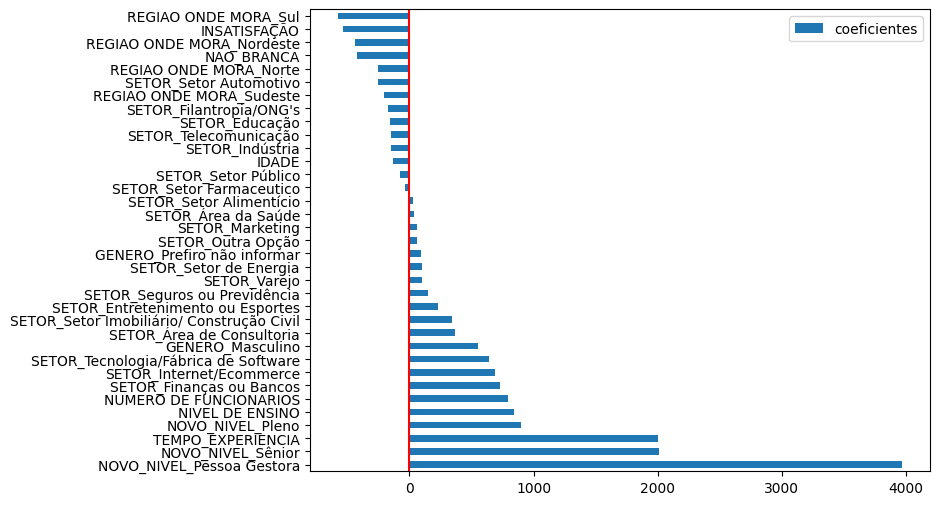

In [ ]:
coefs.plot.barh(figsize=(8,6)) # Gera um gráfico de barras horizontais (`barh`) dos coeficientes.
plt.axvline(x=0, color='red') # O tamanho da figura é definido como (8,6).
# `plt.axvline(x=0, color='red')` adiciona uma linha vertical em x=0 para diferenciar coeficientes positivos (impacto positivo) de negativos (impacto negativo).
# O gráfico mostra visualmente a magnitude e direção do impacto de cada feature no salário.